In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import svm
from sklearn import metrics
import copy

In [ ]:
def draw_svm(clf, x, y, x1_min, x1_max, x2_min, x2_max, target=None):
    """
    Draws the decision boundary of an svm.
    :param clf: sklearn.svm.SVC classifier
    :param x: data Nx2
    :param y: label N
    :param x1_min: minimum value of the x-axis of the plot
    :param x1_max: maximum value of the x-axis of the plot
    :param x2_min: minimum value of the y-axis of the plot
    :param x2_max: maximum value of the y-axis of the plot
    :param target: if target is set to path, the plot is saved to that path
    :return: None
    """
    y = y.astype(bool)
    xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 500),
                         np.linspace(x2_min, x2_max, 500))
    z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)
    disc_z = z > 0
    plt.clf()
    plt.imshow(disc_z, interpolation='nearest',
               extent=(xx.min(), xx.max(), yy.min(), yy.max()), aspect='auto',
               origin='lower', cmap=plt.cm.RdBu, alpha=.3)
    plt.contour(xx, yy, z, levels=[-1, 1], linewidths=2,
                linestyles='dashed', colors=['red', 'blue'], alpha=0.5)
    plt.contour(xx, yy, z, levels=[0], linewidths=2,
                linestyles='solid', colors='black', alpha=0.5)
    positives = x[y == 1]
    negatives = x[y == 0]
    plt.scatter(positives[:, 0], positives[:, 1], s=50, marker='o', color="none", edgecolor="black")
    plt.scatter(negatives[:, 0], negatives[:, 1], s=50, marker='s', color="none", edgecolor="black")
    sv_label = y[clf.support_]
    positive_sv = x[clf.support_][sv_label]
    negative_sv = x[clf.support_][~sv_label]
    plt.scatter(positive_sv[:, 0], positive_sv[:, 1], s=50, marker='o', color="white", edgecolor="black")
    plt.scatter(negative_sv[:, 0], negative_sv[:, 1], s=50, marker='s', color="white", edgecolor="black")
    plt.xlim(x1_min, x1_max)
    plt.ylim(x2_min, x2_max)
    plt.gca().set_aspect('equal', adjustable='box')
    if target is None:
        plt.show()
    else:
        plt.savefig(target)

In [ ]:
## TASK 1 ##
# datasets
train_set = np.load('train_set.npy')
train_lbs = np.load('train_labels.npy')

c value: 0.01


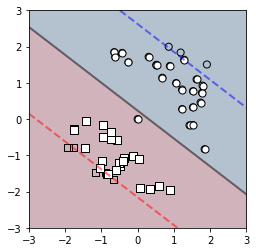

c value: 0.1


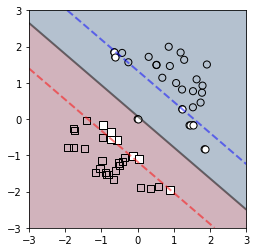

c value: 1


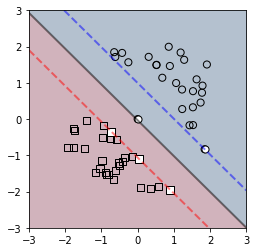

c value: 10


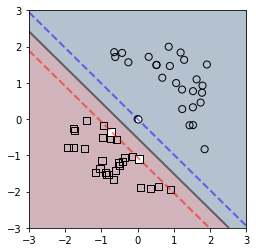

c value: 100


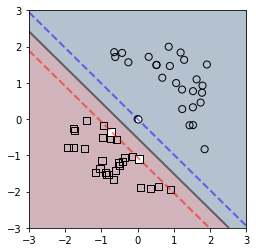

In [ ]:
c_values = [0.01, 0.1, 1, 10, 100]
for i in range(5):
    print("c value:", c_values[i])
    clf = svm.SVC(kernel='linear', C = c_values[i])
    clf.fit(train_set, train_lbs)
    draw_svm(clf, train_set, train_lbs, -3, 3, -3, 3)

In [ ]:
## TASK 2 ##
# datasets
train_set = np.load('train_set.npy')
train_lbs = np.load('train_labels.npy')

kernel func: linear


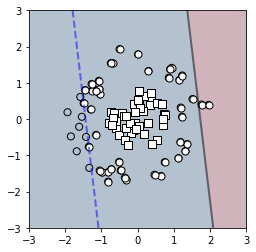

kernel func: rbf


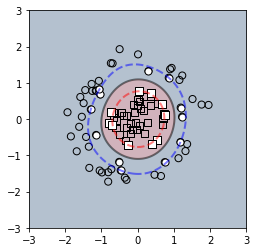

kernel func: poly


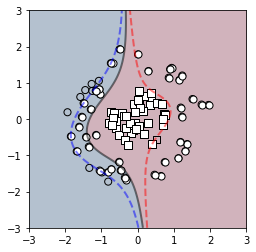

kernel func: sigmoid


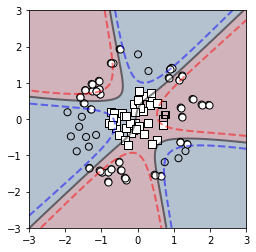

In [ ]:
kernel_functions = ['linear', 'rbf', 'poly', 'sigmoid']
for i in range(4):
    print("kernel func:", kernel_functions[i])
    clf = svm.SVC(kernel=kernel_functions[i], C = 1)
    clf.fit(train_set, train_lbs)
    draw_svm(clf, train_set, train_lbs, -3, 3, -3, 3)

In [ ]:
## TASK 3 ##
train_set = np.load('train_set.npy')
train_labels = np.load('train_labels.npy')
test_set = np.load('test_set.npy')
test_labels = np.load('test_labels.npy')

In [ ]:
def split_train_and_validation(whole_train_data, whole_train_labels, validation_index, k_fold):
    # function i wrote from HW2
    full_size = len(whole_train_labels)
    chunk_size = int(full_size / k_fold)
    start = validation_index * chunk_size
    end = (validation_index + 1) * chunk_size

    val_data, val_labels = whole_train_data[start:end], whole_train_labels[start:end]
    train_data = np.concatenate((whole_train_data[0:start], whole_train_data[end:full_size]))
    train_labels = np.concatenate((whole_train_labels[0:start], whole_train_labels[end:full_size]))

    print("val data shape:", val_data.shape)
    print("val labels shape:", val_labels.shape)
    print("train data shape:", train_data.shape)
    print("train labels shape:", train_labels.shape)

    return train_data, train_labels, val_data, val_labels

In [ ]:
def convert_3D_to_2D(dataset):
    a,b,c = dataset.shape
    new_dataset = []
    for i in range(a):
        new_row = []
        for j in range(b): #32
            for k in range(c): #32
                new_row.append(dataset[i][j][k])
        new_dataset.append(new_row)
    # print("old shape:", len(dataset), len(dataset[0]))
    # print("new shape:", len(new_dataset), len(new_dataset[0]))

    return np.asarray(new_dataset)

In [ ]:
# creating training and validation datasets
train_data, train_labels, val_data, val_labels = split_train_and_validation(train_set, train_labels, 0, 10)

val data shape: (100, 32, 32)
val labels shape: (100,)
train data shape: (900, 32, 32)
train labels shape: (900,)


In [ ]:
# converting the train set into 2D
train_data = convert_3D_to_2D(train_data)
val_data = convert_3D_to_2D(val_data)

In [ ]:
kernel_functions = ['linear', 'rbf', 'poly']
c_values = [0.01, 0.1, 1, 10]
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1]

In [ ]:
max_acc = 0
best_kernel = ""
best_c = 0
best_gamma=0

for kernel in kernel_functions:
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~ kernel change")
    for c in c_values:
        for gamma in gamma_values:
            clf = svm.SVC(C = c, kernel=kernel, gamma=gamma)
            clf.fit(train_data, train_labels)
            prediction_labels = clf.predict(val_data)

            if metrics.accuracy_score(val_labels, prediction_labels) > max_acc:
                max_acc = metrics.accuracy_score(val_labels, prediction_labels)
                best_kernel = kernel
                best_c = c
                best_gamma= gamma

            # print("\n-----------------------")
            # print("VALIDATION RESULTS:\nkernel:", kernel, "c:", c, "gamma:", gamma)
            print("accuracy:",metrics.accuracy_score(val_labels, prediction_labels))
            print("precision:", "%.2f" % round(metrics.precision_score(val_labels, prediction_labels, zero_division=0), 2))
            print("recall:","%.2f" % round(metrics.recall_score(val_labels, prediction_labels), 2))

print("\n******************************")
print("BEST PERFORMANCE WAS ACHIEVED BY")
print("kernel:", best_kernel, "c:", best_c, "gamma:", best_gamma)

~~~~~~~~~~~~~~~~~~~~~~~~~~~ kernel change


ValueError: ignored

In [ ]:
# testing best scoring hyper parameters on the test set
# test_set = convert_3D_to_2D(test_set)
clf = svm.SVC(C = 10, kernel='rbf', gamma=0.01)
clf.fit(train_data, train_labels)
prediction_labels = clf.predict(test_set)

print("TEST RESULTS:\nkernel:", kernel, "c:", c, "gamma:", gamma)
print("accuracy:",metrics.accuracy_score(test_labels, prediction_labels))
print("precision:",metrics.precision_score(test_labels, prediction_labels, zero_division=0))
print("recall:",metrics.recall_score(test_labels, prediction_labels))

TEST RESULTS:
kernel: poly c: 10 gamma: 1
accuracy: 0.805
precision: 0.817047817047817
recall: 0.786


In [ ]:
## TASK 4 ##
train_set = np.load('train_set.npy')
train_labels = np.load('train_labels.npy')
test_set = np.load('test_set.npy')
test_labels = np.load('test_labels.npy')

# converting the train set into 2D
train_data = convert_3D_to_2D(train_set)
test_data = convert_3D_to_2D(test_set)

# Plain results with rbf kernel and C=1
clf = svm.SVC(C = 1, kernel='rbf')
clf.fit(train_data, train_labels)
prediction_labels = clf.predict(test_data)

print("PLAIN RESULTS:\nkernel:", kernel, "c:", c, "gamma:", gamma)
print("accuracy:",metrics.accuracy_score(test_labels, prediction_labels))
print("precision:",metrics.precision_score(test_labels, prediction_labels, zero_division=0))
print("recall:",metrics.recall_score(test_labels, prediction_labels))

PLAIN RESULTS:
kernel: poly c: 10 gamma: 1
accuracy: 0.95
precision: 0.95
recall: 1.0


In [ ]:
# finding majority and minoprity class
ones = 0
zeros = 0
for x in train_labels:
    if x == 1:
        ones = ones +1
    else:
        zeros = zeros +1
print("ones:", ones, "zeros:", zeros)
majority_class = zeros if zeros > ones else ones
minority_class = zeros if zeros < ones else ones
majority = 0 if zeros > ones else 1
minority = 0 if zeros < ones else 1
ratio = int(majority_class/minority_class)


# print("minority_class:", minority_class)
# print("majority_class:", majority_class)
# print("minority:", minority)
# print("majority:", majority)

ones: 950 zeros: 50
minority_class: 50
majority_class: 950
minority: 0
majority: 1


In [ ]:
# Oversampling the minority class of the training set
train_oversampled = copy.deepcopy(train_data)
train_labels_oversampled = copy.deepcopy(train_labels)
train_oversampled = np.asarray(train_oversampled)
train_labels_oversampled = np.asarray(train_labels_oversampled)


minority_data = []
for i in range(train_data.shape[0]):
    if train_labels[i] == minority:
        minority_data.append(train_data[i])

for i in range(ratio -1):
    for j in range(len(minority_data)):
        train_oversampled = np.append(train_oversampled, minority_data[j])
        train_labels_oversampled = np.append(train_labels_oversampled, minority)

train_oversampled = train_oversampled.reshape((train_labels_oversampled.shape[0], 1024))
# print("oversampled shape:", train_oversampled.shape)

# ones = 0
# zeros = 0
# for x in train_labels_oversampled:
#     if x == 1:
#         ones = ones +1
#     else:
#         zeros = zeros +1
# print("ones:", ones, "zeros:", zeros)

19
oversampled shape: (1900, 1024)
ones: 950 zeros: 950


In [ ]:
# oversampled results
clf = svm.SVC(C = 1, kernel='rbf')
clf.fit(train_oversampled, train_labels_oversampled)
prediction_labels = clf.predict(test_data)

print("OVERSAMPLED RESULTS:\nkernel:", kernel, "c:", c, "gamma:", gamma)
print("accuracy:",metrics.accuracy_score(test_labels, prediction_labels))
print("precision:",metrics.precision_score(test_labels, prediction_labels, zero_division=0))
print("recall:",metrics.recall_score(test_labels, prediction_labels))

OVERSAMPLED RESULTS:
kernel: linear c: 0.01 gamma: 0.0001
accuracy: 0.951
precision: 0.9611054247697032
recall: 0.988421052631579


In [ ]:
# Undersampling the minority class of the training set
train_undersampled = copy.deepcopy(train_data)
train_labels_undersampled = copy.deepcopy(train_labels)
train_undersampled = np.asarray(train_undersampled)
train_labels_undersampled = np.asarray(train_labels_undersampled)

for i in range(len(train_data)):
    if train_labels[i] == majority:
        if majority_class > 0:
            train_undersampled = np.append(train_undersampled, train_data[i])
            train_labels_undersampled = np.append(train_labels_undersampled, majority)
            majority_class = majority_class - 1
    else:
        train_undersampled = np.append(train_undersampled, train_data[i])
        train_labels_undersampled = np.append(train_labels_undersampled, minority)

train_undersampled = train_undersampled.reshape((train_labels_undersampled.shape[0], 1024))
print("shape:", train_undersampled.shape)


shape: (1050, 1024)


In [ ]:
# undersampled results
clf = svm.SVC(C = 1, kernel='rbf')
clf.fit(train_undersampled, train_labels_undersampled)
prediction_labels = clf.predict(test_data)

print("OVERSAMPLED RESULTS:\nkernel:", kernel, "c:", c, "gamma:", gamma)
print("accuracy:",metrics.accuracy_score(test_labels, prediction_labels))
print("precision:",metrics.precision_score(test_labels, prediction_labels, zero_division=0))
print("recall:",metrics.recall_score(test_labels, prediction_labels))

OVERSAMPLED RESULTS:
kernel: linear c: 0.01 gamma: 0.0001
accuracy: 0.956
precision: 0.9575757575757575
recall: 0.9978947368421053


In [ ]:
# Adjusting class weight as “balanced”
clf = svm.SVC(C = 1, kernel='rbf', class_weight="balanced")
clf.fit(train_data, train_labels)
prediction_labels = clf.predict(test_data)

print("OVERSAMPLED RESULTS:\nkernel:", kernel, "c:", c, "gamma:", gamma)
print("accuracy:",metrics.accuracy_score(test_labels, prediction_labels))
print("precision:",metrics.precision_score(test_labels, prediction_labels, zero_division=0))
print("recall:",metrics.recall_score(test_labels, prediction_labels))

OVERSAMPLED RESULTS:
kernel: linear c: 0.01 gamma: 0.0001
accuracy: 0.936
precision: 0.9643605870020965
recall: 0.968421052631579
